<a href="https://colab.research.google.com/github/ami-null/python-course/blob/main/14_plotting-with-seaborn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Plotting with Seaborn

Seaborn is a Python data visualization library built on top of matplotlib. It works directly with pandas DataFrames, so you can pass column names instead of raw arrays, and it handles a lot of the styling, aggregation, and legend work that matplotlib leaves to you. It is commonly used for statistical plots like distributions, categorical comparisons, and regression fits, and includes several built-in datasets for practice.

## Learning objectives

By the end of this lecture, you will be able to:

- Create and customize scatter plots, and map extra variables using hue, size and alpha
- Choose between countplot and barplot depending on whether you need frequencies or a summary statistic
- Visualize distributions using histograms, KDE plots and box plots
- Fit and visualize regression lines with regplot and lmplot
- Build a correlation heatmap from numeric data
- Use FacetGrid, PairGrid and jointplot to visualize multiple relationships at once

## Overview

| Function    | What it shows                                                       |
|-------------|---------------------------------------------------------------------|
| scatterplot | relationship between two numeric variables                          |
| countplot   | frequency of categories                                             |
| barplot     | a summary statistic, e.g. mean, per category                        |
| histplot    | distribution of a numeric variable via binned counts                |
| kdeplot     | smoothed estimate of a distribution                                 |
| boxplot     | distribution summary: median, quartiles, outliers                   |
| regplot     | scatter plot with a fitted regression line                          |
| lmplot      | regplot with optional faceting by category                          |
| heatmap     | a matrix of values as color, typically correlations                 |
| FacetGrid   | the same plot repeated across subsets of the data                   |
| PairGrid    | pairwise relationships across all numeric columns                   |
| jointplot   | a bivariate relationship plus each variable's marginal distribution |
| lineplot    | trend of a numeric variable over an ordered variable, e.g. time     |


In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme()
# sns.set_context("paper")
# sns.set_style("whitegrid")

In [2]:
df = sns.load_dataset("penguins")

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            344 non-null    object 
 1   island             344 non-null    object 
 2   bill_length_mm     342 non-null    float64
 3   bill_depth_mm      342 non-null    float64
 4   flipper_length_mm  342 non-null    float64
 5   body_mass_g        342 non-null    float64
 6   sex                333 non-null    object 
dtypes: float64(4), object(3)
memory usage: 18.9+ KB


In [4]:
df.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female


In [5]:
df.species.value_counts()

,count
species,
Adelie,152
Gentoo,124
Chinstrap,68


In [6]:
df.island.value_counts()

,count
island,
Biscoe,168
Dream,124
Torgersen,52


In [7]:
df.sex.value_counts()

,count
sex,
Male,168
Female,165


## Scatter plots

`sns.scatterplot()` plots two numeric variables against each other as points. Use it when you want to see whether two continuous variables are related, and whether that relationship changes across groups.

The cells below build up the same plot one parameter at a time:

- x, y: the columns for the two axes
- hue: a column used to color points by category
- size: a column used to scale point size, useful for showing a third numeric variable
- alpha: point transparency, useful when points overlap

Text(0, 0.5, 'Flipper length (mm)')

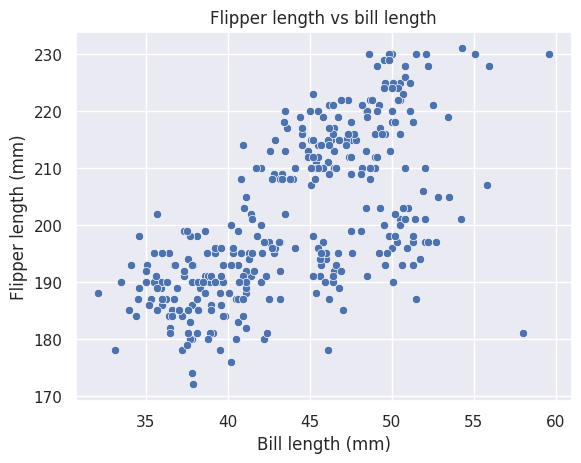

In [8]:
sns.scatterplot(
    data = df,
    x = "bill_length_mm",
    y = "flipper_length_mm"
)
plt.title("Flipper length vs bill length")
plt.xlabel("Bill length (mm)")
plt.ylabel("Flipper length (mm)")

Adding `hue` colors each point by species, which makes it easy to see whether the relationship differs across groups.

(160.0, 240.0)

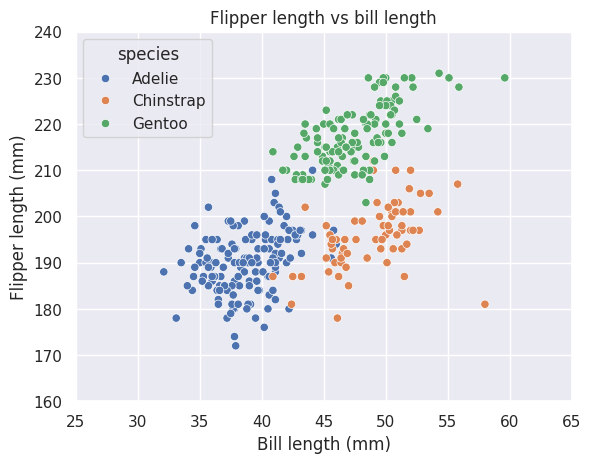

In [9]:
sns.scatterplot(
    data = df,
    x = "bill_length_mm",
    y = "flipper_length_mm",
    hue = "species"
)
plt.title("Flipper length vs bill length")
plt.xlabel("Bill length (mm)")
plt.ylabel("Flipper length (mm)")
plt.xlim([25,65])
plt.ylim([160, 240])

Adding `size` scales each point by a third numeric variable, body mass, so the plot now encodes two categorical/numeric dimensions beyond x and y.

Text(0, 0.5, 'Flipper length (mm)')

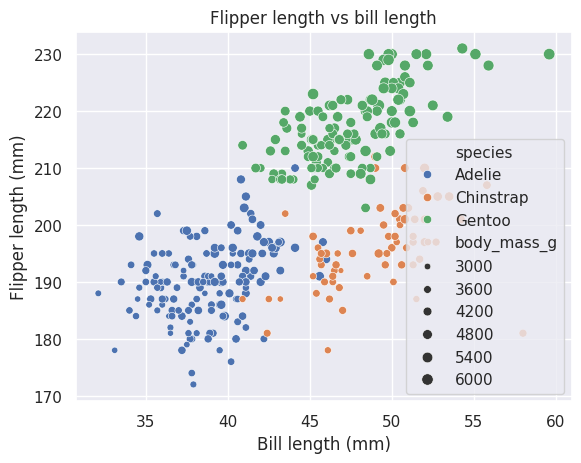

In [10]:
sns.scatterplot(
    data = df,
    x = "bill_length_mm",
    y = "flipper_length_mm",
    hue = "species",
    size = "body_mass_g"
)
plt.title("Flipper length vs bill length")
plt.xlabel("Bill length (mm)")
plt.ylabel("Flipper length (mm)")

With `hue` and `size` both mapped, points start to overlap. Lowering `alpha` makes overlapping points visible, and capturing the plot in `ax` lets us reposition the legend outside the plot area with `sns.move_legend()` instead of letting it cover the data.

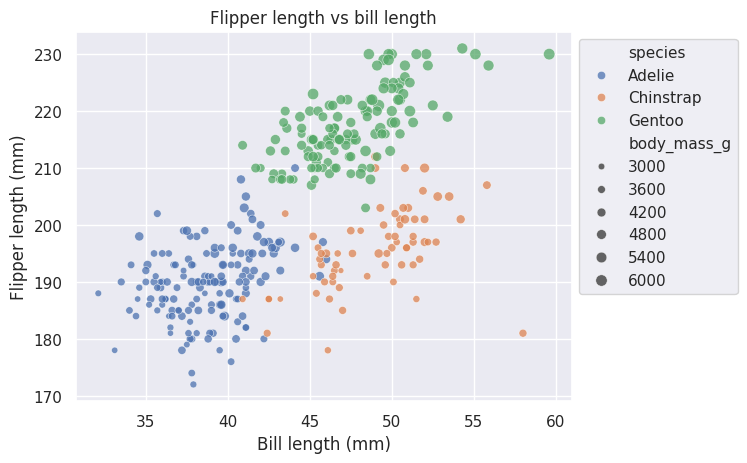

In [11]:
ax = sns.scatterplot(
    data = df,
    x = "bill_length_mm",
    y = "flipper_length_mm",
    hue = "species",
    size = "body_mass_g",
    alpha = 0.75
)
ax.set_title("Flipper length vs bill length")
ax.set_xlabel("Bill length (mm)")
ax.set_ylabel("Flipper length (mm)")

sns.move_legend(
    ax,
    loc = "upper left",
    bbox_to_anchor=(1, 1)
)

## Bar diagram

### countplot vs barplot

Both produce bar charts, but they answer different questions.

`sns.countplot()` counts how many rows fall into each category. It takes only a categorical variable, computes the counts automatically, and needs no numeric column. Use it when the question is *how many*.

`sns.barplot()` shows a summary statistic, by default the mean, of a numeric variable within each category. It requires both a categorical variable and a numeric variable, and draws error bars by default. Use it when the question is *what is the typical value*.

A quick way to remember it: countplot answers "how many", barplot answers "how much on average" (or any other summary statistic).

### Bars representing frequencies (counts)

<Axes: xlabel='island', ylabel='count'>

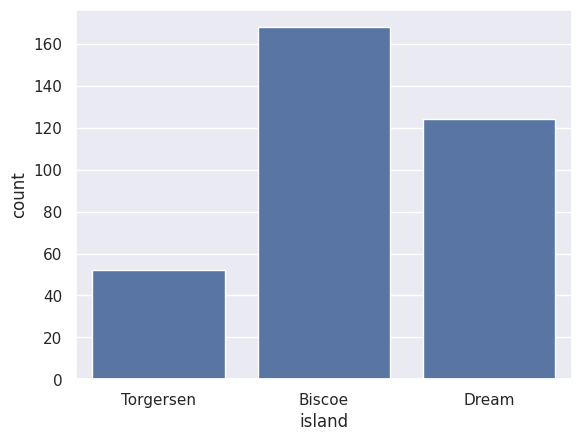

In [12]:
sns.countplot(
    data = df,
    x = "island"
)    # seaborn finds the frequencies automatically

<Axes: xlabel='island', ylabel='count'>

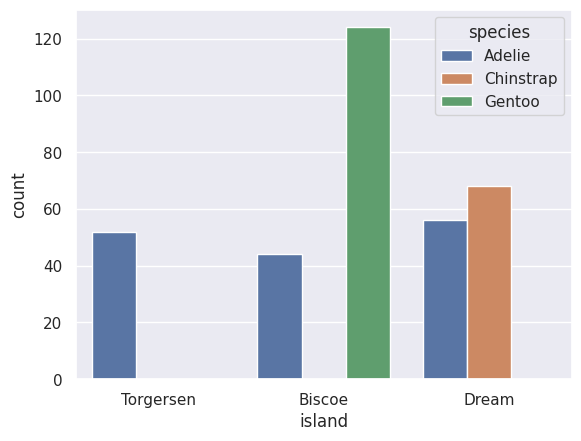

In [13]:
sns.countplot(
    data = df,
    x = "island",
    hue = "species"
)    # seaborn finds the frequencies automatically

### Bars representing other summary statistics

The `estimator` argument controls which statistic is computed per category, and `errorbar` controls how the uncertainty band around that statistic is drawn.

<Axes: xlabel='species', ylabel='body_mass_g'>

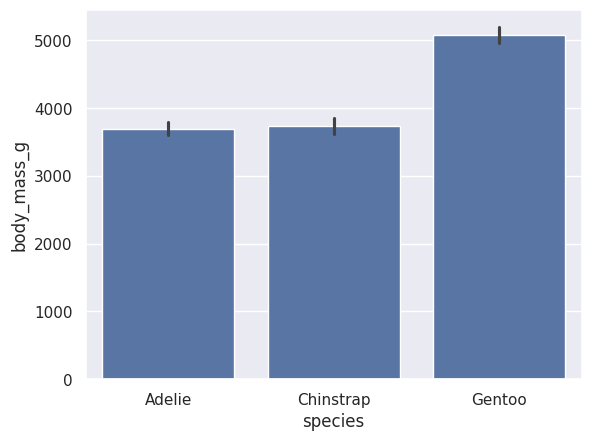

In [14]:
sns.barplot(
    data = df,
    x = "species",
    y = "body_mass_g",
    estimator = "mean",
    errorbar = ("ci", 99)
)    # finds mean of body_mass_g with respect to species

# errorbar: name of errorbar method (either "ci", "pi", "se", or "sd"), or
# a tuple with a method name and a level parameter, or a function that maps from
# a vector to a (min, max) interval, or None to hide the errorbar

<Axes: xlabel='species', ylabel='body_mass_g'>

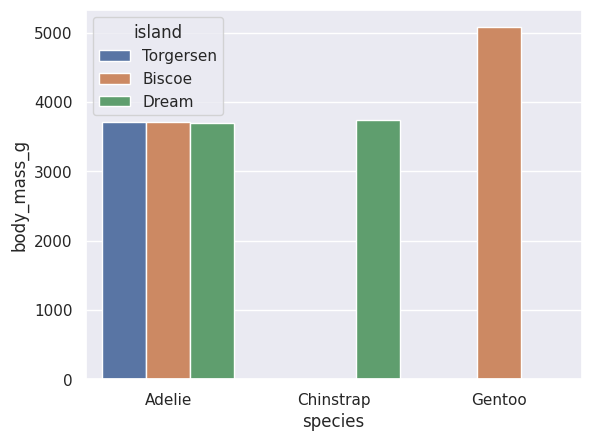

In [15]:
sns.barplot(
    data = df,
    x = "species",
    y = "body_mass_g",
    hue = "island",
    estimator = "mean",
    errorbar = None
)

## Visualizing distribution of numeric variables

### Histogram

`sns.histplot()` prodcues histograms for numeric variables. Use it to see the overall shape of a distribution: is it skewed, bimodal, does it have outliers. The `kde` argument overlays a smoothed density curve, and `stat` controls whether bars show counts, density, or probability.

Text(0.5, 1.0, 'histogram of body mass (g)')

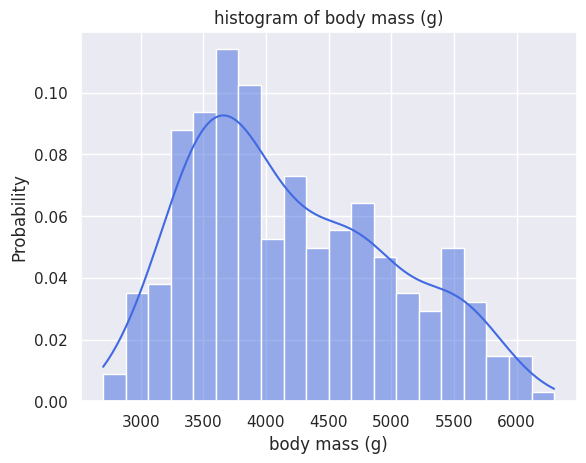

In [16]:
sns.histplot(
    data = df,
    x = "body_mass_g",
    color = "royalblue",
    bins = 20,
    kde = True,
    stat = "probability"
)
plt.xlabel("body mass (g)")
plt.title("histogram of body mass (g)")

How the `stat` argument works:

```
stat: str
    Aggregate statistic to compute in each bin.
        count:     show the number of observations in each bin
        frequency: show the number of observations divided by the bin width
        probability or proportion: normalize such that bar heights sum to 1
        percent:   normalize such that bar heights sum to 100
        density:   normalize such that the total area of the histogram equals 1
```

### KDE plot

sns.kdeplot() shows a smoothed estimate of a distribution without binning. It is useful when you want a cleaner shape than a histogram gives, or when comparing distributions across multiple groups, since overlapping filled curves are easier to read than overlapping bars.

<Axes: xlabel='body_mass_g', ylabel='Density'>

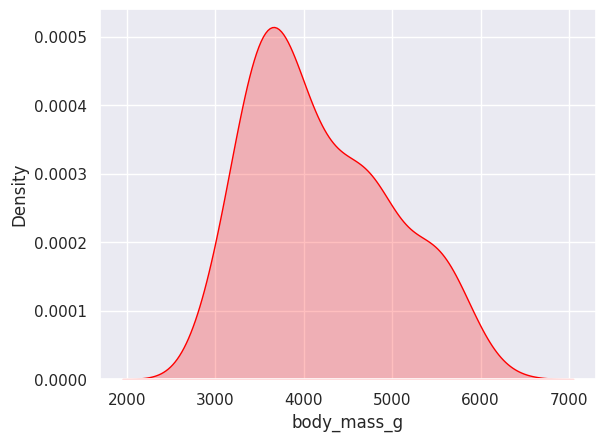

In [17]:
sns.kdeplot(
    data = df,
    x = "body_mass_g",
    fill = True,
    color = "red"
)

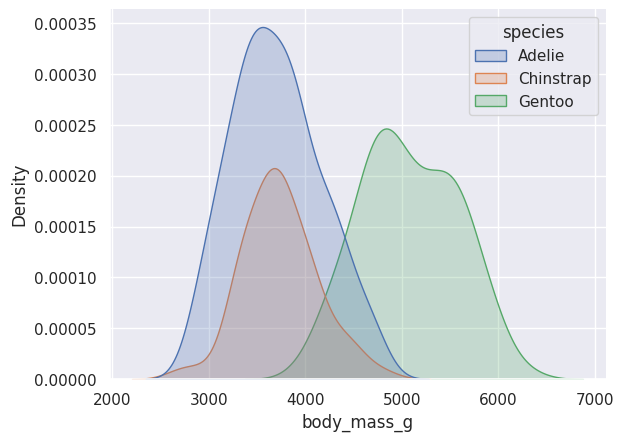

In [18]:
sns.kdeplot(
    data = df,
    x = "body_mass_g",
    hue = "species",
    fill = True
)
sns.despine()

### Boxplot

`sns.boxplot()` summarizes a distribution using five numbers: minimum, first quartile, median, third quartile and maximum, with points beyond 1.5 times the interquartile range shown as outliers. Use it when comparing distributions across several categories side by side, especially when spread and outliers matter more than the exact shape.

<Axes: xlabel='body_mass_g'>

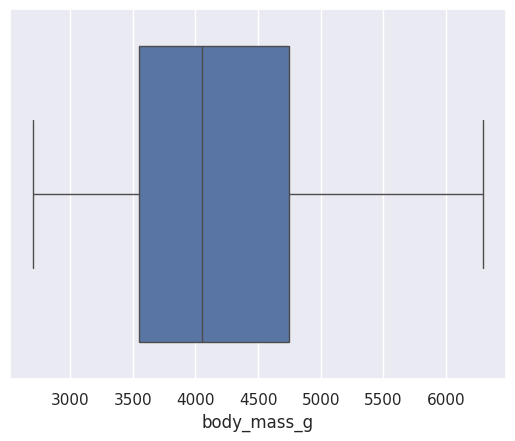

In [19]:
sns.boxplot(
    data = df,
    x = "body_mass_g"
)

<Axes: xlabel='body_mass_g', ylabel='species'>

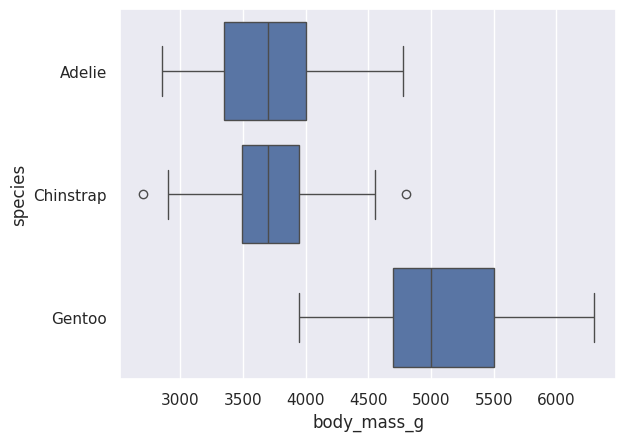

In [20]:
sns.boxplot(
    data = df,
    x = "body_mass_g",
    y = "species"
)

<Axes: xlabel='body_mass_g', ylabel='species'>

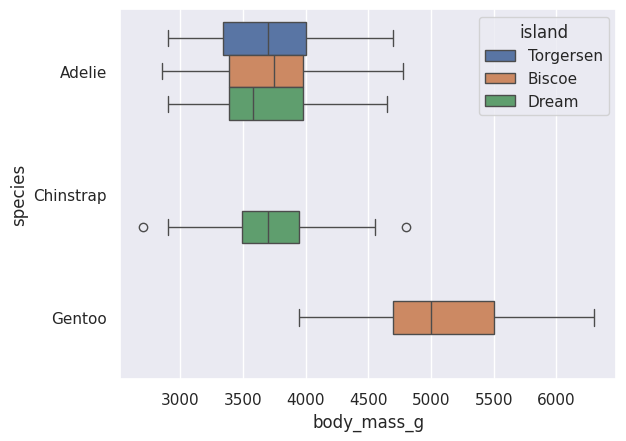

In [21]:
sns.boxplot(
    data = df,
    x = "body_mass_g",
    y = "species",
    hue = "island"
)

## Regression plots: `regplot` and `lmplot`

`sns.regplot()` draws a scatter plot with a fitted linear regression line and a confidence interval band.

`sns.lmplot()` fits the same kind of regression, but it can facet the regression across multiple subplots using `row`, `col` or `hue`. Use `regplot` when you need a regression plot, and `lmplot` when you want the same regression repeated across categories.

Text(0.5, 1.0, 'Flipper length vs bill length, with a fitted regression line')

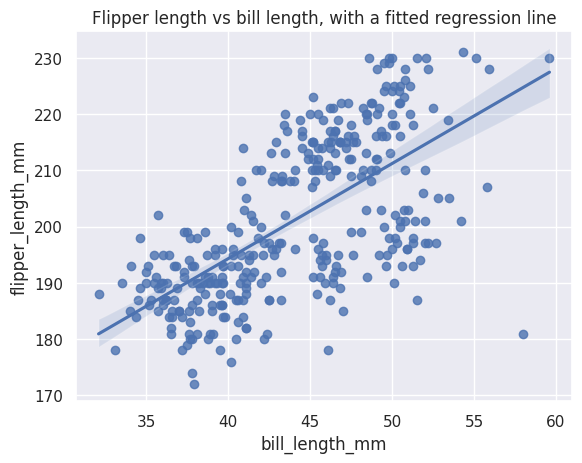

In [22]:
sns.regplot(
    data = df,
    x = "bill_length_mm",
    y = "flipper_length_mm"
)
plt.title("Flipper length vs bill length, with a fitted regression line")

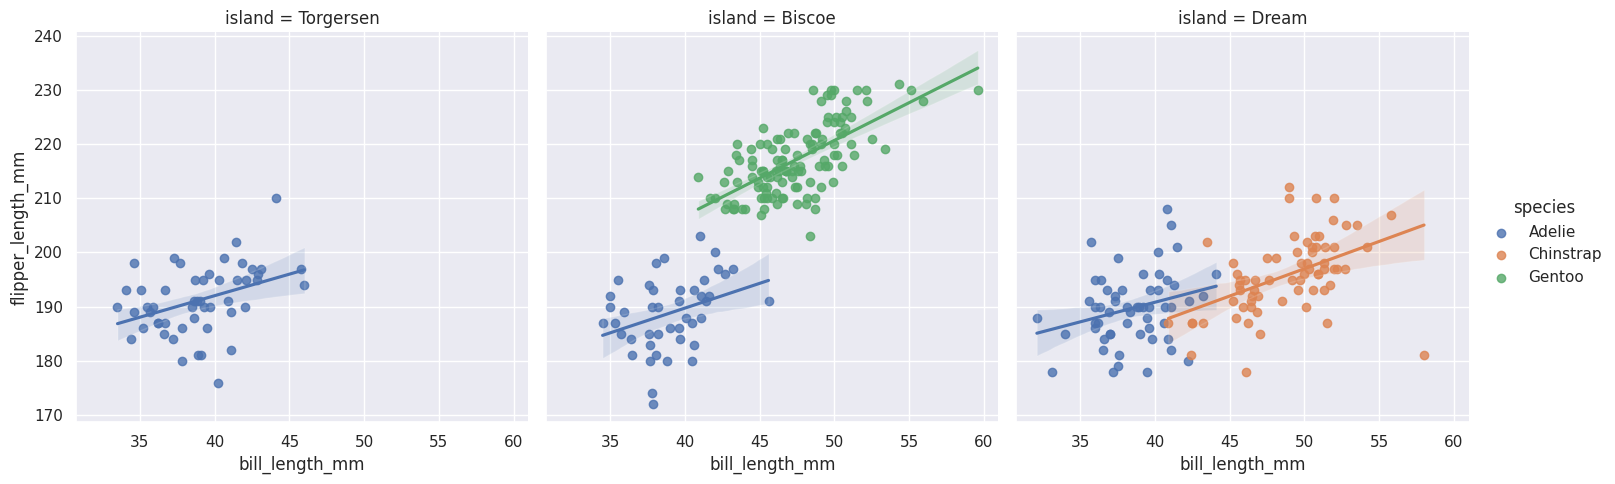

In [23]:
sns.lmplot(
    data = df,
    x = "bill_length_mm",
    y = "flipper_length_mm",
    col = "island",    # NOTE: col means column, there is also an argument called row
    hue = "species"    # NOTE: this is for colour
)    # same regression, fit separately within each species and island subgroups

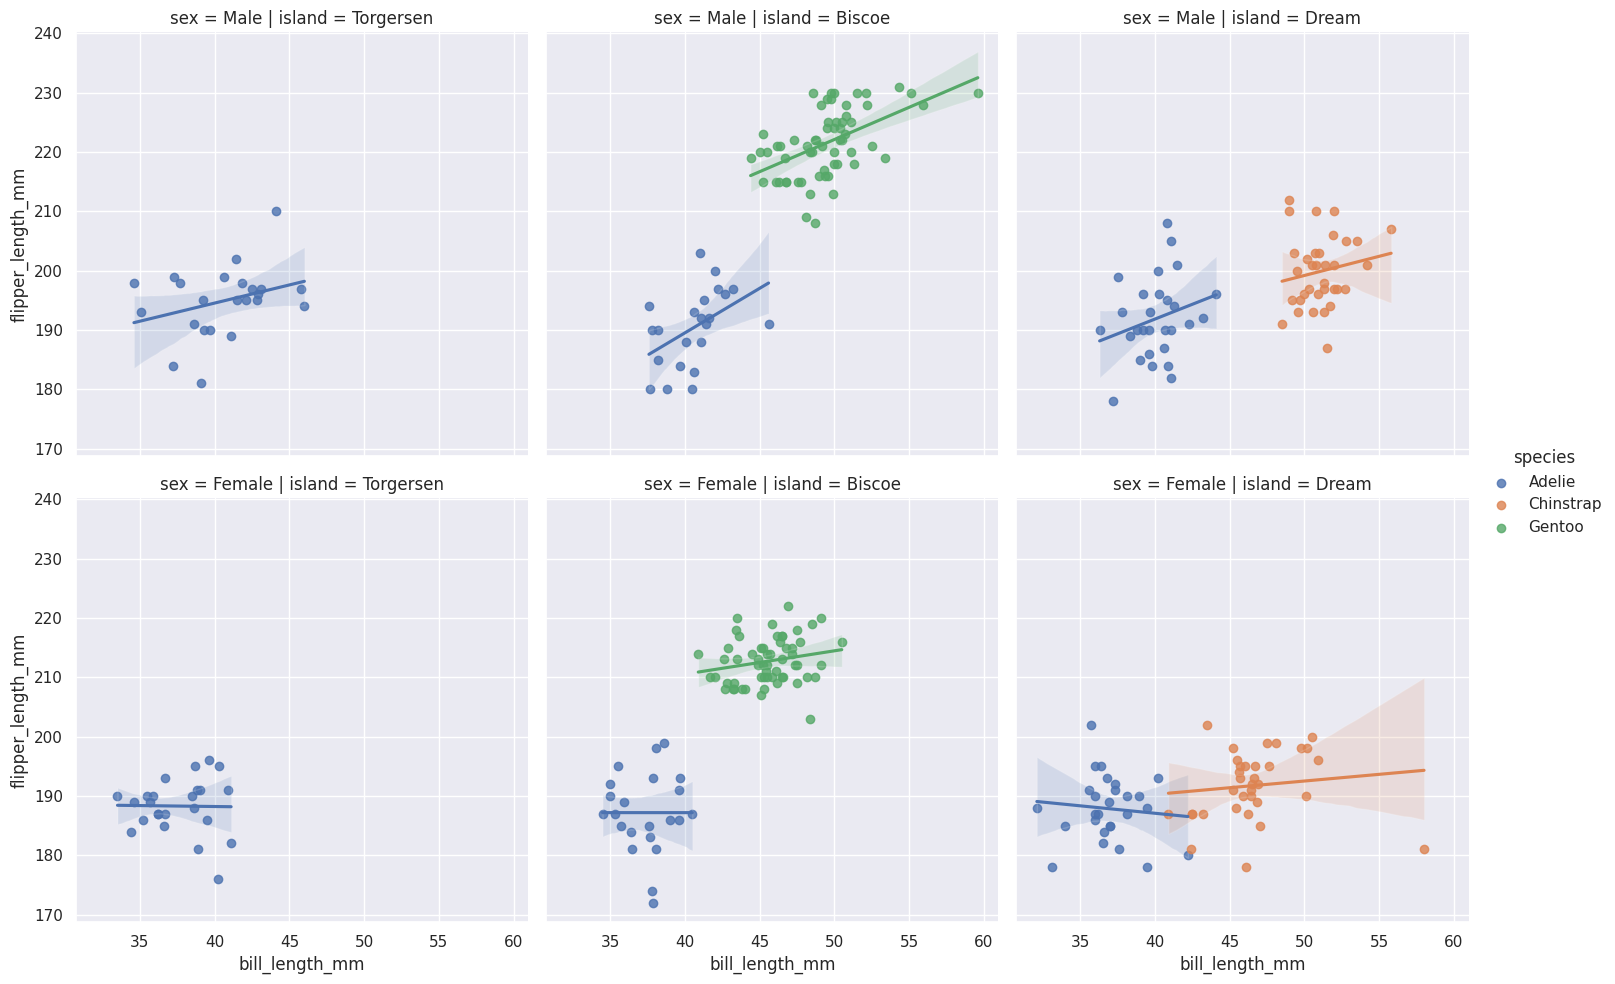

In [24]:
sns.lmplot(
    data = df,
    x = "bill_length_mm",
    y = "flipper_length_mm",
    col = "island",    # NOTE: col means column, there is also an argument called row
    row = "sex",
    hue = "species"    # NOTE: this is for colour
)

## Correlation heatmap

`sns.heatmap()` displays a matrix of values as color, with each cell's value optionally printed as text via `annot`. The most common use is visualizing a correlation matrix: after computing `df.corr()` on the numeric columns, the heatmap makes it easy to spot strong positive or negative relationships at a glance without scanning a table of numbers.

In [25]:
numeric_cols = df.select_dtypes(include = "number")
corr_matrix = numeric_cols.corr()
corr_matrix

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g
bill_length_mm,1.000000,-0.235053,0.656181,0.595110
bill_depth_mm,-0.235053,1.000000,-0.583851,-0.471916
flipper_length_mm,0.656181,-0.583851,1.000000,0.871202
body_mass_g,0.595110,-0.471916,0.871202,1.000000


Text(0.5, 1.0, 'Correlation between numeric penguin measurements')

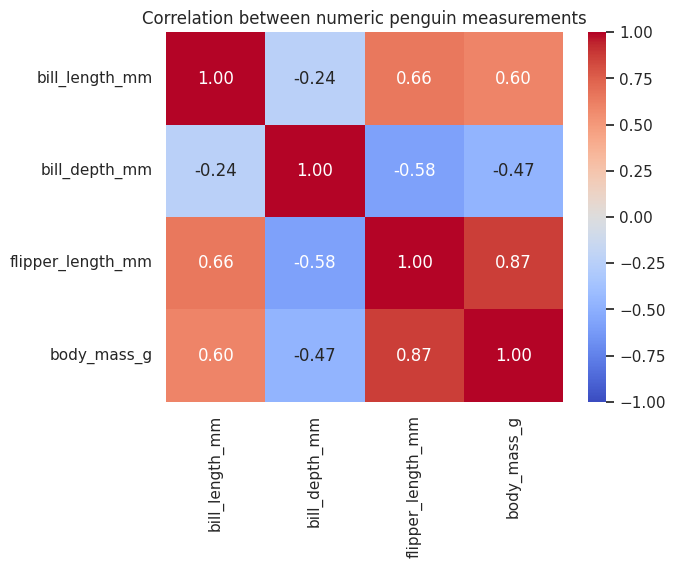

In [26]:
sns.heatmap(
    corr_matrix,
    annot = True,
    fmt = ".2f",
    cmap = "coolwarm",
    vmin = -1,
    vmax = 1
)
plt.title("Correlation between numeric penguin measurements")

### Jointplot

`sns.jointplot()` shows a single bivariate relationship in the center along with each variable's individual distribution along the margins. The `kind` argument changes the central plot: the default draws a scatter plot, `kind="kde"` draws a bivariate density, and `kind="reg"` adds a fitted regression line. Use it when both the relationship between two variables and their individual distributions matter together, such as checking whether a regression assumption of roughly normal marginals holds.

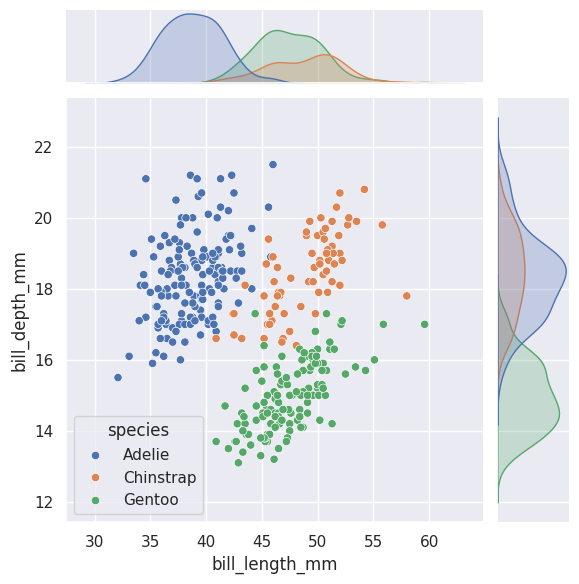

In [27]:
sns.jointplot(data = df, x = "bill_length_mm", y = "bill_depth_mm", hue = "species")

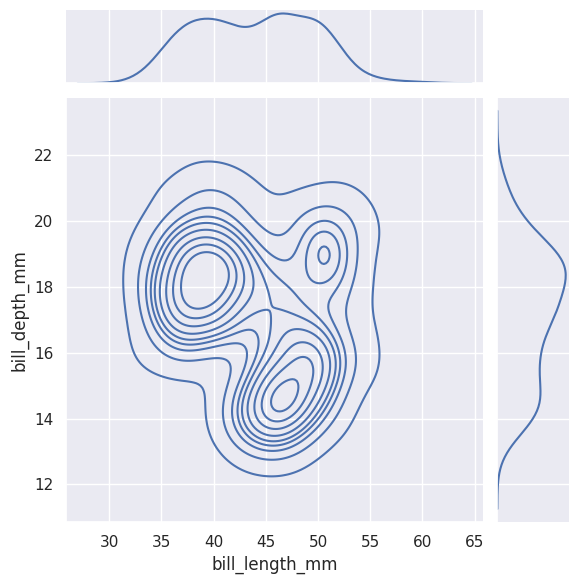

In [28]:
sns.jointplot(data = df, x = "bill_length_mm", y = "bill_depth_mm", kind = "kde")

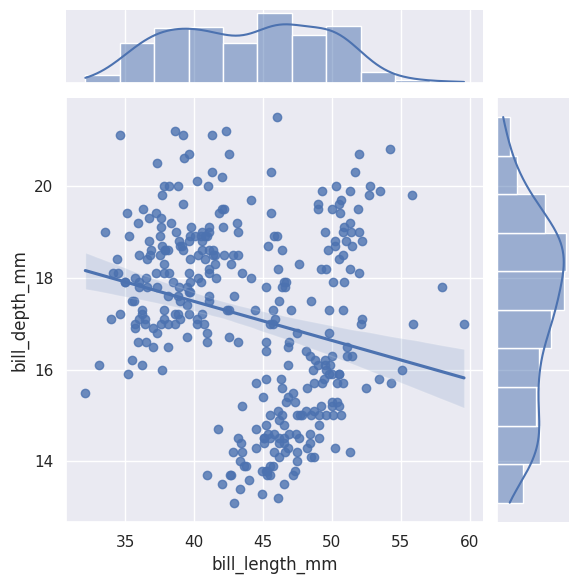

In [29]:
sns.jointplot(data = df, x = "bill_length_mm", y = "bill_depth_mm", kind = "reg")

## Multi-plot grids

### FacetGrid

`sns.FacetGrid() creates` a grid of subplots based on the levels of one or more categorical variables, then repeats the same plotting function on each subset. Use it when you want to see how a relationship changes across combinations of categories, for example whether the bill length vs flipper length relationship looks different by sex and island. Pass `row` and `col` to split the grid, `hue` to color within each subplot, then call `.map()` with the plotting function and the columns to plot.

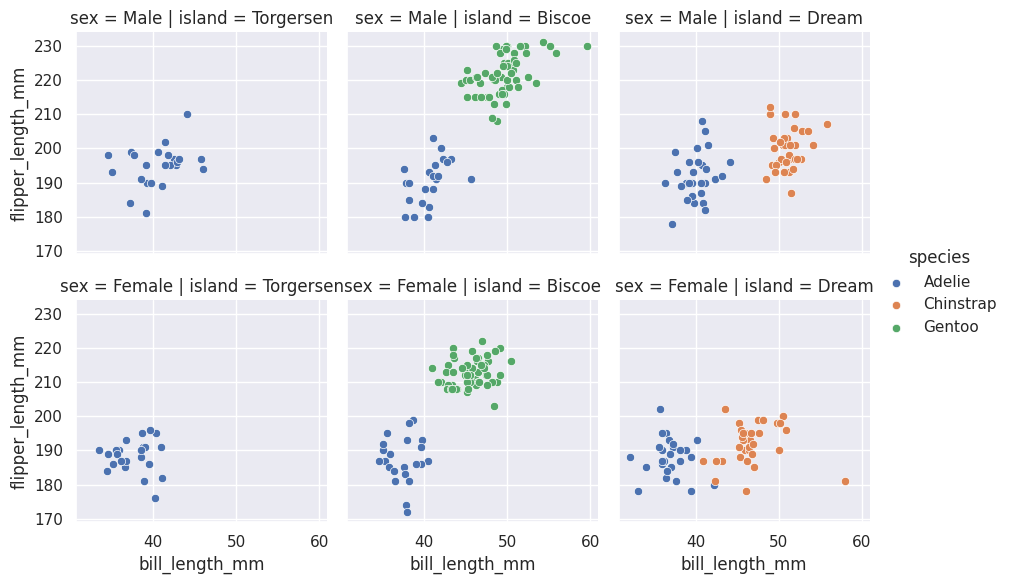

In [30]:
fig = sns.FacetGrid(df, row = "sex", col = "island", hue = "species")
fig.map(sns.scatterplot, "bill_length_mm", "flipper_length_mm").add_legend()

### PairGrid

`sns.PairGrid()` plots every pairwise combination of numeric columns in a grid, with one row and one column per variable. Use it as an exploratory step early in an analysis, to scan for relationships between many variables at once rather than building each scatter plot individually. `.map_upper()`, `.map_lower()` and `.map_diag()` let you use a different plot type for the upper triangle, lower triangle and diagonal, for example scatter plots off the diagonal and density plots on it.

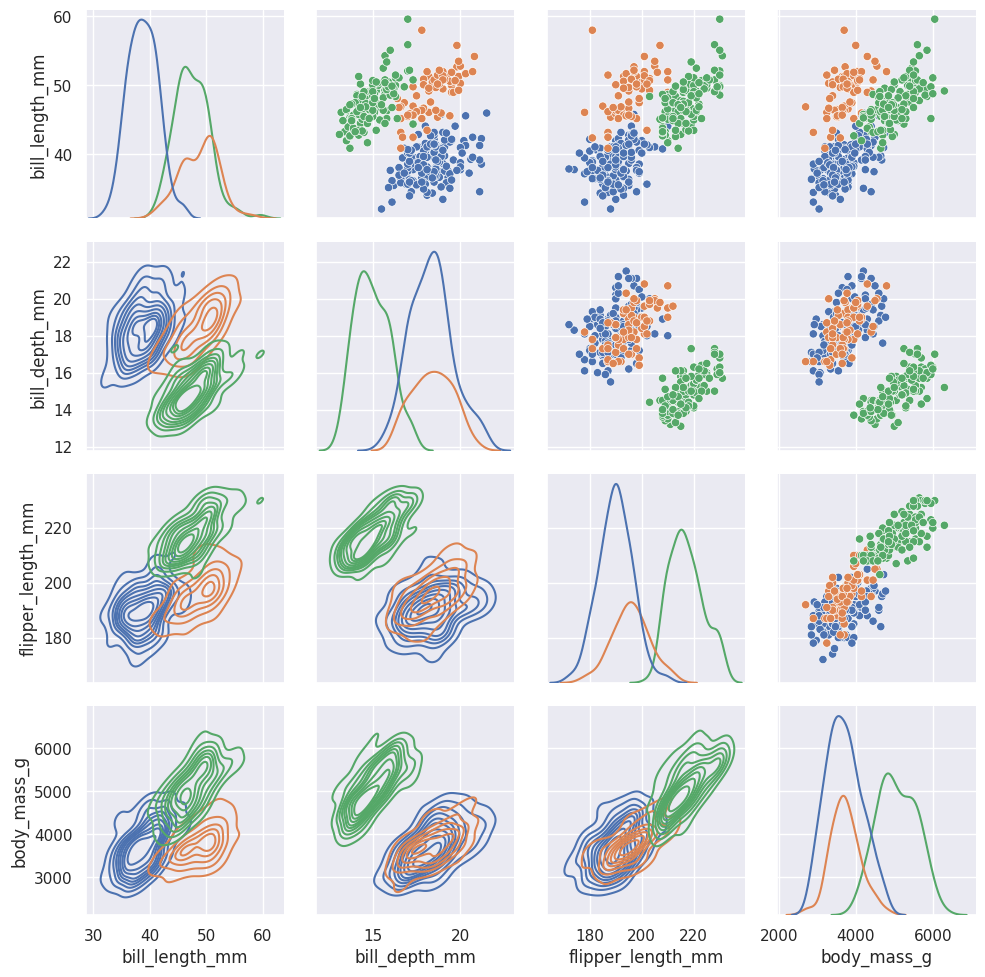

In [31]:
g = sns.PairGrid(df, hue = "species", diag_sharey=False)
g.map_upper(sns.scatterplot)
g.map_lower(sns.kdeplot)
g.map_diag(sns.kdeplot)

## Line plots

`sns.lineplot()` plots a numeric variable against an ordered variable, most commonly time, and is the standard choice for time series or any sequence of repeated measurements. When multiple observations share the same x value, lineplot aggregates them and draws a confidence interval band by default.

The penguins dataset has no ordered or repeated-measurement variable, so this section switches to seaborn's built-in `fmri` dataset, which records brain signal measurements over time for different events and regions.

In [32]:
fmri = sns.load_dataset("fmri")
fmri.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1064 entries, 0 to 1063
Data columns (total 5 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   subject    1064 non-null   object 
 1   timepoint  1064 non-null   int64  
 2   event      1064 non-null   object 
 3   region     1064 non-null   object 
 4   signal     1064 non-null   float64
dtypes: float64(1), int64(1), object(3)
memory usage: 41.7+ KB


<Axes: xlabel='timepoint', ylabel='signal'>

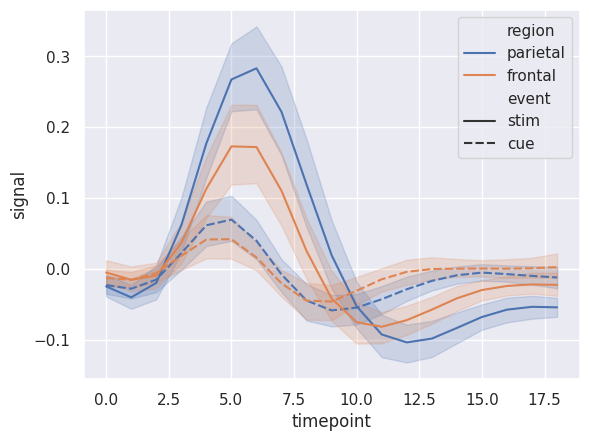

In [33]:
# plot the responses for different events and regions
sns.lineplot(
    data = fmri,
    x = "timepoint",
    y = "signal",
    hue = "region",
    style = "event"
)

## Exercises

The exercises below use seaborn's built-in `tips` dataset, which records restaurant bills, tips and details about each table. Load it with `sns.load_dataset("tips")` before starting.

1. Create a scatter plot of `total_bill` vs `tip`, colored by `time` (Lunch/Dinner).

2. Create a count plot showing how many parties there are for each `day`, split by `smoker` status.

3. Create a new column for tip percentage (`tip` divided by `total_bill`). Then create a bar plot showing the mean tip percentage for each `day`, with `time` as the hue.

4. Plot the distribution of `total_bill` two ways: a histogram with a KDE overlay, and a KDE plot split by `sex`. Compare what each version tells you.

5. Create a box plot of `tip` by `day`, with `smoker` as the hue.

6. Use `regplot` to fit a regression line of `tip` vs `total_bill`. Then use `lmplot` to repeat the same regression separately for each value of `time`.

7. Compute the correlation matrix of the numeric columns in `tips` and display it as a heatmap with annotated values.

8. Use `jointplot` with `kind="reg"` to show the relationship between `total_bill` and `tip` along with their marginal distributions.